# ProstT5 Baseline Performance

Benchmarks two prediction pipelines on a 100-protein test set for both directions:

| Pipeline | Inv-folding (3Di → AA) | Folding (AA → 3Di) |
|---|---|---|
| `enc_dec` | ProstT5 encoder + autoregressive decoder | same |
| `enc_cnn` | ProstT5 encoder + CNN head (one parallel pass) | same |

**Architecture note:** the encoder runs **once** per protein per direction; \
its hidden states are reused for both the decoder timing pass and the CNN timing pass.

**Prerequisite:** Run `100_protein_dataset.ipynb` first, then upload \
`test_set_AA.fasta`, `test_set_3Di.fasta`, `cnn_chkpnt_AA_CNN/model.pt`, \
and `cnn_chkpnt_folding/model.pt` to `/content/drive/MyDrive/models/` on Google Drive.

In [1]:
%pip install -q sentencepiece 'transformers>=4.40' 'accelerate>=0.26'


In [2]:
import os, time, gc, statistics, math, pickle, shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS = Path('/content/drive/MyDrive/models')
    USE_DRIVE = True
    print(f'Drive mounted. Models dir: {DRIVE_MODELS}')
except (ImportError, ModuleNotFoundError):
    DRIVE_MODELS = None
    USE_DRIVE = False
    print('Not on Colab — using local paths.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('WARNING: timings on CPU will not reflect GPU performance.')


Mounted at /content/drive
Drive mounted. Models dir: /content/drive/MyDrive/models
Device: cuda


In [3]:
# @title [Optional] GPU Memory Cleanup â€” run before re-running the notebook
_to_clear = ['model', 'encoder', 'cnn', 'cnn_assistant']
for _v in _to_clear:
    if _v in globals():
        del globals()[_v]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory cleared.  Free: {free/1e9:.1f} GB / {total/1e9:.1f} GB total")
else:
    print("No CUDA GPU â€” nothing to clear.")

GPU memory cleared.  Free: 15.5 GB / 15.6 GB total


In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
PROSTT5_NAME = 'Rostlab/ProstT5_fp16'
NOTEBOOK_DIR = Path('.').resolve()
RESULTS_DIR  = NOTEBOOK_DIR / 'benchmark_results'
RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR = RESULTS_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Drive subfolder for all baseline results
DRIVE_RESULTS = (DRIVE_MODELS / 'benchmark_results') if USE_DRIVE else None
if DRIVE_RESULTS: DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

# ── Benchmark protocol ────────────────────────────────────────────────────────
NUM_REPEATS  = 5     # timed passes per measurement (median reported)
NUM_PROTEINS = None    # None = all; int = use N shortest proteins

# ── Alphabets ─────────────────────────────────────────────────────────────────
AA_LETTERS = 'ACDEFGHIKLMNPQRSTVWY'
DI_LETTERS = 'acdefghiklmnpqrstvwy'


def _find(*candidates):
    for p in candidates:
        if p is not None and Path(p).exists():
            return Path(p)
    return None


# ── CNN checkpoint discovery ─────────────────────────────────────────────────
INV_CNN_CKPT = _find(
    DRIVE_MODELS / 'CNN_from3di_toAA.pt'              if USE_DRIVE else None,
    NOTEBOOK_DIR / 'cnn_chkpnt_AA_CNN' / 'model.pt',
)
FOLD_CNN_CKPT = _find(
    DRIVE_MODELS / 'CNN_fromAA_to3Di.pt'              if USE_DRIVE else None,
    NOTEBOOK_DIR / 'cnn_chkpnt_folding' / 'model.pt',
)

print(f'Inv-fold CNN : {INV_CNN_CKPT  or "NOT FOUND"}')
print(f'Folding  CNN : {FOLD_CNN_CKPT or "NOT FOUND"}')

Inv-fold CNN : /content/drive/MyDrive/models/CNN_from3di_toAA.pt
Folding  CNN : /content/drive/MyDrive/models/CNN_fromAA_to3Di.pt


In [5]:
# ── Load test set from FASTA files ───────────────────────────────────────────
def _read_fasta(path):
    seqs, cur = {}, None
    for line in Path(path).read_text().splitlines():
        if line.startswith('>'):
            cur = line[1:].split()[0]
            seqs[cur] = ''
        elif cur:
            seqs[cur] += line.strip()
    return seqs


AA_FASTA = _find(
    DRIVE_MODELS / 'test_set_AA.fasta'   if USE_DRIVE else None,
    NOTEBOOK_DIR / 'dataset' / 'test_set_AA.fasta',
    NOTEBOOK_DIR / 'benchmark_data' / 'test_set_AA.fasta',
)
DI_FASTA = _find(
    DRIVE_MODELS / 'test_set_3Di.fasta'  if USE_DRIVE else None,
    NOTEBOOK_DIR / 'dataset' / 'test_set_3Di.fasta',
    NOTEBOOK_DIR / 'benchmark_data' / 'test_set_3Di.fasta',
)

if AA_FASTA is None or DI_FASTA is None:
    raise FileNotFoundError(
        'FASTA files not found. Run 100_protein_dataset.ipynb first, '
        'then upload test_set_AA.fasta and test_set_3Di.fasta to '
        '/content/drive/MyDrive/models/ on Google Drive.'
    )

aa_seqs = _read_fasta(AA_FASTA)
di_seqs = _read_fasta(DI_FASTA)
assert set(aa_seqs) == set(di_seqs), 'Mismatched protein sets between FASTA files'

ALL_PROTEINS = sorted(
    [{'id': uid, 'aa': aa_seqs[uid], '3di': di_seqs[uid], 'length': len(aa_seqs[uid])}
     for uid in aa_seqs],
    key=lambda x: x['length'],
)
benchmark_proteins = ALL_PROTEINS[:NUM_PROTEINS] if NUM_PROTEINS else ALL_PROTEINS

print(f'Loaded {len(ALL_PROTEINS)} proteins; benchmarking {len(benchmark_proteins)}.')
print(f'Length range: {ALL_PROTEINS[0]["length"]}–{ALL_PROTEINS[-1]["length"]} residues')


Loaded 100 proteins; benchmarking 100.
Length range: 46–2554 residues


In [6]:
# ── Load ProstT5 ──────────────────────────────────────────────────────────────
tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)

dtype = torch.float16 if device.type == 'cuda' else torch.float32
model = AutoModelForSeq2SeqLM.from_pretrained(
    PROSTT5_NAME, torch_dtype=dtype, low_cpu_mem_usage=True,
).to(device).eval()

# Reuse the same encoder object for both the enc-dec and enc-CNN paths
encoder = model.get_encoder()

print(f'ProstT5: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params, dtype={dtype}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/5.64G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/5.64G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

ProstT5: 2818.9M params, dtype=torch.float16


In [7]:
# ── CNN head (shared architecture for both directions) ────────────────────────
class CNN(nn.Module):
    def __init__(self, num_tokens=20, hidden=32, in_dim=1024):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(in_dim, hidden, (7, 1), padding=(3, 0)),
            nn.ReLU(),
            nn.Dropout(0.0),
            nn.Conv2d(hidden, num_tokens, (7, 1), padding=(3, 0)),
        )

    def forward(self, x):
        # x: (B, L, in_dim)  →  (B, L, num_tokens)
        return self.classifier(x.permute(0, 2, 1).unsqueeze(-1)).squeeze(-1).permute(0, 2, 1)


def _load_cnn(path):
    m = CNN().to(device).eval()
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m.load_state_dict(ckpt.get('state_dict', ckpt), strict=True)
    return m


inv_cnn  = _load_cnn(INV_CNN_CKPT)  if INV_CNN_CKPT  else None
fold_cnn = _load_cnn(FOLD_CNN_CKPT) if FOLD_CNN_CKPT else None

n = sum(p.numel() for p in CNN().parameters())
print(f'CNN architecture: {n:,} params')
print(f'Inv-folding CNN  (3Di→AA): {"loaded" if inv_cnn  else "NOT FOUND — enc_cnn skipped"}')
print(f'Folding CNN      (AA→3Di): {"loaded" if fold_cnn else "NOT FOUND — enc_cnn_folding skipped"}')


CNN architecture: 233,908 params
Inv-folding CNN  (3Di→AA): loaded
Folding CNN      (AA→3Di): loaded


In [8]:
# ── Timing utilities + tokenisation helpers ────────────────────────────────────
def _sync():
    if   device.type == 'cuda': torch.cuda.synchronize()
    elif device.type == 'mps':  torch.mps.synchronize()

def _reset_peak():
    if device.type == 'cuda': torch.cuda.reset_peak_memory_stats()

def _peak_gb():
    return torch.cuda.max_memory_allocated() / 1e9 if device.type == 'cuda' else 0.0

def _format_3di(seq): return '<fold2AA> ' + ' '.join(seq.lower())
def _format_aa(seq):  return '<AA2fold> ' + ' '.join(seq.upper())

def _decode_aa(ids):
    return ''.join(tokenizer.decode(ids, skip_special_tokens=True).split())

def _decode_3di(ids):
    ids = ids if isinstance(ids, list) else ids.tolist()
    return ''.join(tokenizer.decode(ids, skip_special_tokens=True).split()).lower()

print('Helpers defined.')


Helpers defined.


In [9]:
# ── Core benchmark function ───────────────────────────────────────────────────
@torch.inference_mode()
def benchmark_direction(uid, seq, direction):
    """
    Time enc-dec and enc-CNN for one protein in one direction.

    The encoder runs once; its output is shared between the decoder timing pass
    and the CNN timing pass (no redundant encoder computation).

    direction: 'inv'  -> 3Di input, AA  output  (pipelines: enc_dec, enc_cnn)
               'fold' -> AA  input, 3Di output  (pipelines: enc_dec_folding, enc_cnn_folding)

    Returns (rows, pred_dec, pred_cnn).
    """
    L       = len(seq)
    cnn_m   = inv_cnn    if direction == 'inv'  else fold_cnn
    letters = AA_LETTERS if direction == 'inv'  else DI_LETTERS
    pl_dec  = 'enc_dec'          if direction == 'inv' else 'enc_dec_folding'
    pl_cnn  = 'enc_cnn'          if direction == 'inv' else 'enc_cnn_folding'
    fmt     = _format_3di(seq)   if direction == 'inv' else _format_aa(seq)
    decode  = _decode_aa         if direction == 'inv' else _decode_3di

    enc_inp = tokenizer([fmt], add_special_tokens=True, return_tensors='pt').to(device)
    gen_kw  = dict(
        input_ids=enc_inp.input_ids, attention_mask=enc_inp.attention_mask,
        max_length=L + 2, min_length=L + 1, num_beams=1, do_sample=False,
    )

    # ── Encoder (shared for decoder + CNN) ───────────────────────────────────
    enc_t, enc_pk = [], []
    for _ in range(NUM_REPEATS):
        _reset_peak(); _sync()
        t0 = time.perf_counter()
        enc_out = encoder(input_ids=enc_inp.input_ids, attention_mask=enc_inp.attention_mask)
        _sync()
        enc_t.append(time.perf_counter() - t0)
        enc_pk.append(_peak_gb())
    t_enc = statistics.median(enc_t)

    # ── Decoder (encoder NOT re-run — uses cached enc_out) ───────────────────
    dec_kw = {**gen_kw, 'encoder_outputs': enc_out}
    dec_t, dec_pk, out_dec = [], [], None
    for _ in range(NUM_REPEATS):
        _reset_peak(); _sync()
        t0 = time.perf_counter()
        out_dec = model.generate(**dec_kw)
        _sync()
        dec_t.append(time.perf_counter() - t0)
        dec_pk.append(_peak_gb())
    pred_dec = decode(out_dec[0])[:L]

    # ── CNN (encoder NOT re-run — uses cached hidden states) ─────────────────
    h_cnn = enc_out.last_hidden_state[:, 1:-1, :].float()
    if cnn_m is not None:
        cnn_t, cnn_pk, ids = [], [], None
        for _ in range(NUM_REPEATS):
            _reset_peak(); _sync()
            t0 = time.perf_counter()
            ids = cnn_m(h_cnn).argmax(-1)
            _sync()
            cnn_t.append(time.perf_counter() - t0)
            cnn_pk.append(_peak_gb())
        pred_cnn = ''.join(letters[int(i)] for i in ids[0].tolist())
    else:
        cnn_t = [float('nan')] * NUM_REPEATS
        cnn_pk, pred_cnn = [0.0], ''

    def _row(pipeline, tail_times, pk_tail, pred):
        tots  = [te + tt for te, tt in zip(enc_t, tail_times)]
        valid = [t for t in tots if not math.isnan(t)]
        t_tot = statistics.median(valid) if valid else float('nan')
        vtail = [t for t in tail_times if not math.isnan(t)]
        return {
            'protein_id':    uid,   'pipeline':     pipeline,
            'length':        L,     'latency_s':    t_tot,
            'latency_s_std': float(np.std(valid)) if len(valid) > 1 else float('nan'),
            'enc_s':         t_enc, 'tail_s':       statistics.median(vtail) if vtail else float('nan'),
            'tail_s_std':    float(np.std(vtail))  if len(vtail) > 1 else float('nan'),
            'tokens_per_s':  L / t_tot if t_tot > 0 and not math.isnan(t_tot) else float('nan'),
            'peak_vram_gb':  max(enc_pk + pk_tail),
            'pred':          pred,
        }

    return [_row(pl_dec, dec_t, dec_pk, pred_dec),
            _row(pl_cnn, cnn_t, cnn_pk, pred_cnn)], pred_dec, pred_cnn


print('benchmark_direction() defined.')

benchmark_direction() defined.


In [10]:
# ── Checkpointing + progress tracking ────────────────────────────────────────
CHECKPOINT_PKL = CHECKPOINT_DIR / 'baseline_checkpoint.pkl'


def save_checkpoint(state):
    state['timestamp'] = datetime.now().isoformat()
    with open(CHECKPOINT_PKL, 'wb') as f:
        pickle.dump(state, f)
    if USE_DRIVE:
        DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
        shutil.copy(CHECKPOINT_PKL, DRIVE_RESULTS / 'baseline_checkpoint.pkl')


def load_checkpoint():
    if CHECKPOINT_PKL.exists():
        with open(CHECKPOINT_PKL, 'rb') as f:
            return pickle.load(f)
    if USE_DRIVE:
        drive_pkl = DRIVE_RESULTS / 'baseline_checkpoint.pkl'
        if drive_pkl.exists():
            shutil.copy(drive_pkl, CHECKPOINT_PKL)
            print('Restored checkpoint from Drive.')
            with open(CHECKPOINT_PKL, 'rb') as f:
                return pickle.load(f)
    return None


class ProgressTracker:
    def __init__(self, total):
        self.total, self.done = total, 0
        self._t0, self._times = time.time(), []

    def update(self, uid, elapsed):
        self.done += 1
        self._times.append(elapsed)
        avg = sum(self._times) / len(self._times)
        eta = (self.total - self.done) * avg / 60
        elapsed_total = (time.time() - self._t0) / 60
        print(f'  [{self.done}/{self.total}] {uid}  {elapsed:.1f}s  '
              f'ETA {eta:.0f} min  elapsed {elapsed_total:.0f} min')


ckpt = load_checkpoint()
if ckpt:
    print(f'Found checkpoint: {len(ckpt.get("completed", []))} proteins done '
          f'({ckpt.get("timestamp", "")})')
else:
    print('No checkpoint found — starting fresh.')

Restored checkpoint from Drive.
Found checkpoint: 91 proteins done (2026-06-06T19:08:10.076308)


In [11]:
# ── Main benchmark loop ────────────────────────────────────────────────────────
ckpt = load_checkpoint()
if ckpt is not None:
    all_rows    = ckpt['all_rows']
    predictions = ckpt['predictions']
    completed   = set(ckpt['completed'])
    print(f'Resuming: {len(completed)} proteins already done.')
else:
    all_rows, predictions, completed = [], {}, set()

remaining = [p for p in benchmark_proteins if p['id'] not in completed]
print(f'Total: {len(benchmark_proteins)},  done: {len(completed)},  remaining: {len(remaining)}')

tracker = ProgressTracker(total=len(benchmark_proteins))
tracker.done = len(completed)

for item in remaining:
    uid, aa, di, L = item['id'], item['aa'], item['3di'], item['length']
    t_start = time.perf_counter()
    print(f'\n[{tracker.done + 1}/{tracker.total}] {uid}  L={L}')

    # Inverse folding (3Di → AA)
    rows_inv, pred_dec_inv, pred_cnn_inv = benchmark_direction(uid, di, 'inv')
    for r in rows_inv:
        if not math.isnan(r['latency_s']):
            print(f'  {r["pipeline"]:<20s} {r["latency_s"]:.2f}s  '
                  f'(enc {r["enc_s"]:.2f}s + tail {r["tail_s"]:.3f}s)')

    # Folding (AA → 3Di)
    rows_fold, pred_dec_fold, pred_cnn_fold = benchmark_direction(uid, aa, 'fold')
    for r in rows_fold:
        if not math.isnan(r['latency_s']):
            print(f'  {r["pipeline"]:<20s} {r["latency_s"]:.2f}s  '
                  f'(enc {r["enc_s"]:.2f}s + tail {r["tail_s"]:.3f}s)')

    all_rows.extend(rows_inv + rows_fold)
    predictions[uid] = {
        'enc_dec':          pred_dec_inv,
        'enc_cnn':          pred_cnn_inv,
        'enc_dec_folding':  pred_dec_fold,
        'enc_cnn_folding':  pred_cnn_fold,
        'ground_truth_aa':  aa,
        'ground_truth_3di': di,
        'length':           L,
    }
    completed.add(uid)
    save_checkpoint({'all_rows': all_rows, 'predictions': predictions,
                     'completed': list(completed)})

    tracker.update(uid, time.perf_counter() - t_start)
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print(f'\nDone: {len(completed)} proteins, {len(all_rows)} timed rows.')


Resuming: 91 proteins already done.
Total: 100,  done: 91,  remaining: 9

[92/100] P02458  L=1487
  enc_dec              54.66s  (enc 1.14s + tail 53.526s)
  enc_cnn              1.14s  (enc 1.14s + tail 0.001s)
  enc_dec_folding      54.11s  (enc 1.21s + tail 52.893s)
  enc_cnn_folding      1.21s  (enc 1.21s + tail 0.001s)
  [92/100] P02458  559.9s  ETA 75 min  elapsed 9 min

[93/100] P22579  L=1536
  enc_dec              56.19s  (enc 1.19s + tail 55.001s)
  enc_cnn              1.19s  (enc 1.19s + tail 0.001s)
  enc_dec_folding      55.66s  (enc 1.20s + tail 54.461s)
  enc_cnn_folding      1.20s  (enc 1.20s + tail 0.001s)
  [93/100] P22579  559.8s  ETA 65 min  elapsed 19 min

[94/100] Q02880  L=1626
  enc_dec              58.94s  (enc 1.25s + tail 57.689s)
  enc_cnn              1.25s  (enc 1.25s + tail 0.001s)
  enc_dec_folding      59.78s  (enc 1.25s + tail 58.527s)
  enc_cnn_folding      1.25s  (enc 1.25s + tail 0.001s)
  [94/100] Q02880  594.1s  ETA 57 min  elapsed 29 min

[95/10

In [12]:
# ── Aggregate and save results ─────────────────────────────────────────────────
import pandas as pd

raw = pd.DataFrame(all_rows)
raw.to_csv(RESULTS_DIR / 'raw_runs.csv', index=False)

summary = (
    raw.groupby(['protein_id', 'pipeline', 'length'])
    .agg(
        latency_s_median=('latency_s',     'first'),
        latency_s_std   =('latency_s_std', 'first'),  # std of NUM_REPEATS runs
        enc_s_median    =('enc_s',         'first'),
        tail_s_median   =('tail_s',        'first'),
        tail_s_std      =('tail_s_std',    'first'),
        tokens_per_s    =('tokens_per_s', 'median'),
        peak_vram_gb    =('peak_vram_gb', 'max'),
    )
    .reset_index()
    .sort_values(['pipeline', 'length'])
)
summary.to_csv(RESULTS_DIR / 'summary_per_protein.csv', index=False)

# Mirror to Drive so spec-dec notebooks can load baseline timings
if USE_DRIVE:
    DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
    shutil.copy(RESULTS_DIR / 'summary_per_protein.csv',
                DRIVE_MODELS / 'summary_per_protein.csv')  # root copy for spec-dec notebooks
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    shutil.copy(RESULTS_DIR / 'summary_per_protein.csv',
                DRIVE_RESULTS / 'summary_per_protein.csv')
    print(f'Mirrored summary_per_protein.csv to Drive (root + benchmark_results/).')

print('\n=== Summary per pipeline ===')
for pl in sorted(summary['pipeline'].unique()):
    sub = summary[summary['pipeline'] == pl]
    lat, enc, tail, tps = (sub['latency_s_median'], sub['enc_s_median'],
                           sub['tail_s_median'],    sub['tokens_per_s'])
    print(f'{pl}:')
    print(f'  latency   median={lat.median():.2f}s  [{lat.min():.2f}, {lat.max():.2f}]')
    print(f'  enc       median={enc.median():.2f}s')
    print(f'  tail      median={tail.median():.3f}s')
    print(f'  tok/s     median={tps.median():.1f}')

Mirrored summary_per_protein.csv to Drive (root + benchmark_results/).

=== Summary per pipeline ===
enc_cnn:
  latency   median=0.24s  [0.04, 3.02]
  enc       median=0.24s
  tail      median=0.001s
  tok/s     median=1668.6
enc_cnn_folding:
  latency   median=0.24s  [0.03, 3.01]
  enc       median=0.24s
  tail      median=0.001s
  tok/s     median=1647.7
enc_dec:
  latency   median=15.07s  [1.94, 97.40]
  enc       median=0.24s
  tail      median=14.835s
  tok/s     median=27.1
enc_dec_folding:
  latency   median=15.20s  [1.61, 98.26]
  enc       median=0.24s
  tail      median=14.962s
  tok/s     median=27.0


In [13]:
# ── Sequence recovery ─────────────────────────────────────────────────────────
def seq_rec(pred, gt):
    if not pred or not gt:
        return float('nan')
    n = min(len(pred), len(gt))
    return sum(p == g for p, g in zip(pred[:n], gt[:n])) / len(gt)

rec_rows = []
for uid, p in predictions.items():
    gt_aa, gt_di = p['ground_truth_aa'], p['ground_truth_3di']
    rec_rows.append({
        'protein_id':         uid,
        'length':             p['length'],
        'inv_dec_vs_gt_aa':   seq_rec(p['enc_dec'],         gt_aa),
        'inv_cnn_vs_gt_aa':   seq_rec(p['enc_cnn'],         gt_aa),
        'fold_dec_vs_gt_3di': seq_rec(p['enc_dec_folding'], gt_di),
        'fold_cnn_vs_gt_3di': seq_rec(p['enc_cnn_folding'], gt_di),
        'inv_dec_cnn_agree':  seq_rec(p['enc_dec'],         p['enc_cnn'])         if p['enc_cnn']         else float('nan'),
        'fold_dec_cnn_agree': seq_rec(p['enc_dec_folding'], p['enc_cnn_folding']) if p['enc_cnn_folding'] else float('nan'),
    })

rec_df = pd.DataFrame(rec_rows)
rec_df.to_csv(RESULTS_DIR / 'sequence_recovery.csv', index=False)

_RECOVERY_COLS = [
    ('inv_dec_vs_gt_aa',   'enc-dec  inv  vs GT-AA '),
    ('inv_cnn_vs_gt_aa',   'enc-CNN  inv  vs GT-AA '),
    ('fold_dec_vs_gt_3di', 'enc-dec  fold vs GT-3Di'),
    ('fold_cnn_vs_gt_3di', 'enc-CNN  fold vs GT-3Di'),
    ('inv_dec_cnn_agree',  'dec\u2194CNN agree  inv '),
    ('fold_dec_cnn_agree', 'dec\u2194CNN agree fold '),
]
_lines = ['=== Sequence Recovery ===']
for col, label in _RECOVERY_COLS:
    v = rec_df[col].dropna()
    if len(v):
        _lines.append(f'  {label}: {v.mean():.3f}  (\u00b1{v.std():.3f})')
_summary = '\n'.join(_lines)
print(_summary)

_summary_txt = RESULTS_DIR / 'sequence_recovery_summary.txt'
_summary_txt.write_text(_summary)

if USE_DRIVE:
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    shutil.copy(RESULTS_DIR / 'sequence_recovery.csv',        DRIVE_RESULTS / 'sequence_recovery.csv')
    shutil.copy(_summary_txt, DRIVE_RESULTS / 'sequence_recovery_summary.txt')
    print(f'Saved to Drive: benchmark_results/sequence_recovery.csv + .txt')


=== Sequence Recovery ===
  enc-dec  inv  vs GT-AA : 0.456  (±0.253)
  enc-CNN  inv  vs GT-AA : 0.255  (±0.070)
  enc-dec  fold vs GT-3Di: 0.715  (±0.182)
  enc-CNN  fold vs GT-3Di: 0.665  (±0.105)
  dec↔CNN agree  inv : 0.272  (±0.109)
  dec↔CNN agree fold : 0.674  (±0.139)
Saved to Drive: benchmark_results/sequence_recovery.csv + .txt


Saved to Drive: benchmark_results/baseline_plots.png


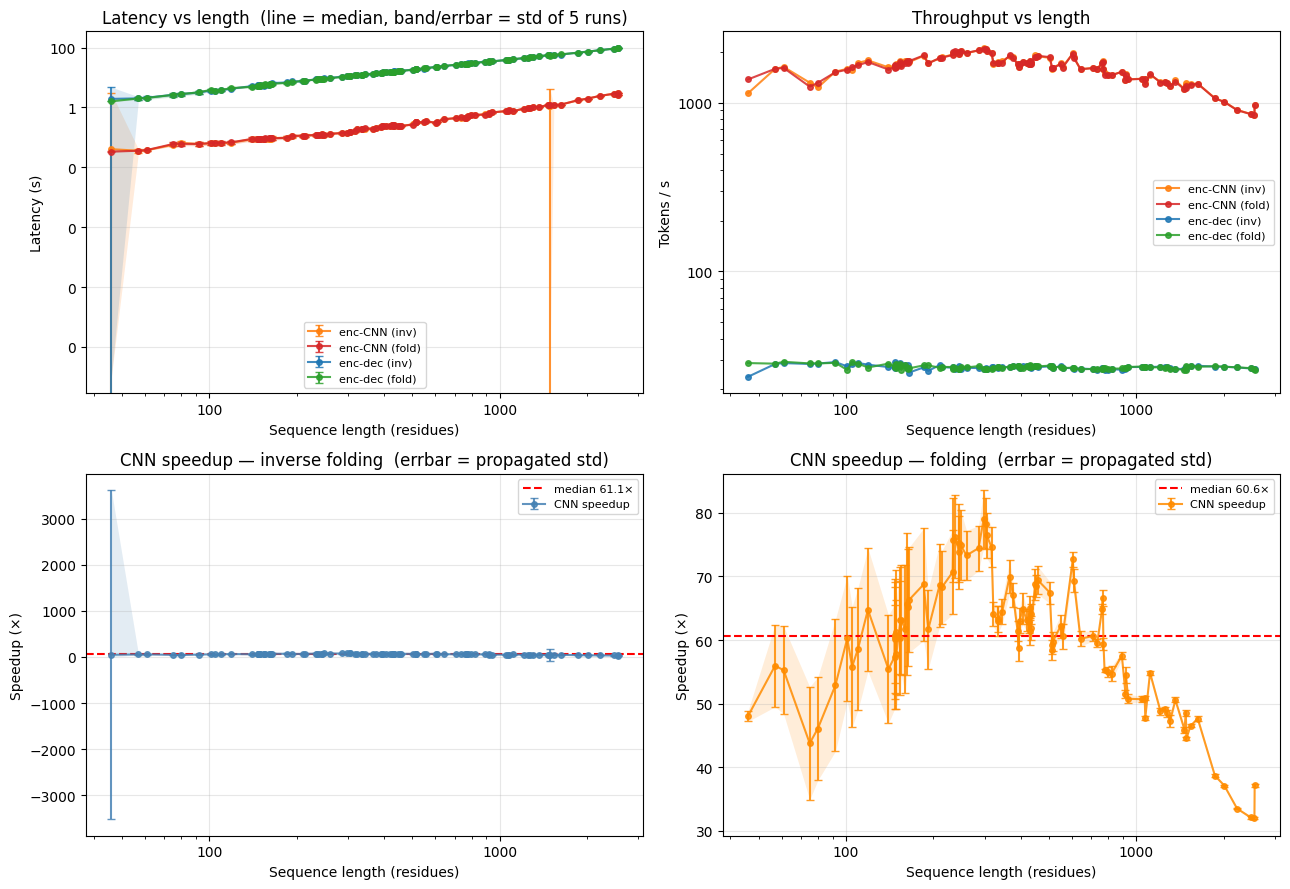

Saved to Colab runtime (ephemeral): /content/benchmark_results/baseline_plots.png


In [14]:
%matplotlib inline
# ── Plots ────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def _scalar_fmt(ax):
    """Show plain numbers (100, 500, 1000) instead of 10^2, 10^3 on log axes."""
    for axis in (ax.xaxis, ax.yaxis):
        fmt = ScalarFormatter()
        fmt.set_scientific(False)
        axis.set_major_formatter(fmt)

COLORS = {
    'enc_dec':         '#1f77b4',
    'enc_cnn':         '#ff7f0e',
    'enc_dec_folding': '#2ca02c',
    'enc_cnn_folding': '#d62728',
}
LABELS = {
    'enc_dec':         'enc-dec (inv)',
    'enc_cnn':         'enc-CNN (inv)',
    'enc_dec_folding': 'enc-dec (fold)',
    'enc_cnn_folding': 'enc-CNN (fold)',
}

def _pivot_speedup(pl_dec, pl_cnn):
    sub = summary[summary['pipeline'].isin([pl_dec, pl_cnn])]
    med = sub.pivot(index='protein_id', columns='pipeline', values='latency_s_median').dropna()
    if pl_dec not in med.columns or pl_cnn not in med.columns:
        return None
    std_piv = sub.pivot(index='protein_id', columns='pipeline', values='latency_s_std').reindex(med.index).fillna(0)
    med = med.copy()
    med['speedup']     = med[pl_dec] / med[pl_cnn]
    med['speedup_err'] = med['speedup'] * np.sqrt(
        (std_piv[pl_dec] / med[pl_dec].replace(0, float('nan'))).fillna(0) ** 2 +
        (std_piv[pl_cnn] / med[pl_cnn].replace(0, float('nan'))).fillna(0) ** 2
    )
    med = med.merge(summary[['protein_id', 'length']].drop_duplicates(), on='protein_id')
    return med.sort_values('length')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Latency vs length ─────────────────────────────────────────────────────────
ax = axes[0, 0]
for pl, sub in summary.groupby('pipeline'):
    sub = sub.sort_values('length')
    col = COLORS.get(pl, 'gray')
    xs  = sub['length'].values
    ys  = sub['latency_s_median'].values
    err = sub['latency_s_std'].fillna(0).values
    ax.fill_between(xs, np.maximum(ys - err, 1e-9), ys + err, color=col, alpha=0.15, linewidth=0)
    ax.errorbar(xs, ys, yerr=err, fmt='o-', markersize=4, linewidth=1.5,
                capsize=3, alpha=0.85, color=col, label=LABELS.get(pl, pl))
ax.set_xscale('log'); ax.set_yscale('log')
_scalar_fmt(ax)
ax.set_xlabel('Sequence length (residues)'); ax.set_ylabel('Latency (s)')
ax.set_title(f'Latency vs length  (line = median, band/errbar = std of {NUM_REPEATS} runs)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Throughput vs length ──────────────────────────────────────────────────────
ax = axes[0, 1]
for pl, sub in summary.groupby('pipeline'):
    sub = sub.sort_values('length')
    col = COLORS.get(pl, 'gray')
    ax.plot(sub['length'], sub['tokens_per_s'], 'o-', markersize=4,
            linewidth=1.5, alpha=0.85, color=col, label=LABELS.get(pl, pl))
ax.set_xscale('log'); ax.set_yscale('log')
_scalar_fmt(ax)
ax.set_xlabel('Sequence length (residues)'); ax.set_ylabel('Tokens / s')
ax.set_title('Throughput vs length')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── CNN speedup — inverse folding ─────────────────────────────────────────────
ax = axes[1, 0]
piv = _pivot_speedup('enc_dec', 'enc_cnn')
if piv is not None:
    xs, ys, err = piv['length'].values, piv['speedup'].values, piv['speedup_err'].fillna(0).values
    ax.fill_between(xs, np.maximum(ys - err, 0), ys + err, color='steelblue', alpha=0.15, linewidth=0)
    ax.errorbar(xs, ys, yerr=err, fmt='o-', markersize=4, linewidth=1.5,
                capsize=3, alpha=0.85, color='steelblue', label='CNN speedup')
    med_sp = float(np.nanmedian(ys))
    ax.axhline(med_sp, color='red', linestyle='--', label=f'median {med_sp:.1f}×')
    ax.set_xscale('log')
    _scalar_fmt(ax)
    ax.set_xlabel('Sequence length (residues)'); ax.set_ylabel('Speedup (×)')
    ax.set_title('CNN speedup — inverse folding  (errbar = propagated std)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── CNN speedup — folding ─────────────────────────────────────────────────────
ax = axes[1, 1]
piv2 = _pivot_speedup('enc_dec_folding', 'enc_cnn_folding')
if piv2 is not None:
    xs2, ys2, err2 = piv2['length'].values, piv2['speedup'].values, piv2['speedup_err'].fillna(0).values
    ax.fill_between(xs2, np.maximum(ys2 - err2, 0), ys2 + err2, color='darkorange', alpha=0.15, linewidth=0)
    ax.errorbar(xs2, ys2, yerr=err2, fmt='o-', markersize=4, linewidth=1.5,
                capsize=3, alpha=0.85, color='darkorange', label='CNN speedup')
    med_sp2 = float(np.nanmedian(ys2))
    ax.axhline(med_sp2, color='red', linestyle='--', label=f'median {med_sp2:.1f}×')
    ax.set_xscale('log')
    _scalar_fmt(ax)
    ax.set_xlabel('Sequence length (residues)'); ax.set_ylabel('Speedup (×)')
    ax.set_title('CNN speedup — folding  (errbar = propagated std)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.tight_layout()
out_path = RESULTS_DIR / 'baseline_plots.png'
fig.savefig(out_path, dpi=150)
if USE_DRIVE:
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    shutil.copy(out_path, DRIVE_RESULTS / 'baseline_plots.png')
    print(f'Saved to Drive: benchmark_results/baseline_plots.png')
plt.show()
print(f'Saved to Colab runtime (ephemeral): {out_path}')

## Separated Direction Plots

The cells below re-plot the same data with **inverse folding** (3Di → AA) and **folding** (AA → 3Di) in separate figures, then a final combined speedup comparison.

In [ ]:
# ── Direction-specific plot helpers (reuse _scalar_fmt/_pivot_speedup from b13) ──

def _plot_lat(ax, pipelines, colors, labels):
    std_col = 'latency_s_std' if 'latency_s_std' in summary.columns else None
    for pl in pipelines:
        sub = summary[summary['pipeline'] == pl].sort_values('length')
        col = colors[pl]
        xs, ys = sub['length'].values, sub['latency_s_median'].values
        err = sub[std_col].fillna(0).values if std_col else np.zeros_like(ys)
        ax.fill_between(xs, np.maximum(ys - err, 1e-9), ys + err,
                        color=col, alpha=0.15, linewidth=0)
        ax.errorbar(xs, ys, yerr=err, fmt='o-', markersize=4, linewidth=1.5,
                    capsize=3, alpha=0.85, color=col, label=labels[pl])
    ax.set_xscale('log'); ax.set_yscale('log')
    _scalar_fmt(ax)
    ax.set_xlabel('Sequence length'); ax.set_ylabel('Latency (s)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

def _plot_tput(ax, pipelines, colors, labels):
    for pl in pipelines:
        sub = summary[summary['pipeline'] == pl].sort_values('length')
        ax.plot(sub['length'], sub['tokens_per_s'], 'o-', markersize=4,
                linewidth=1.5, alpha=0.85, color=colors[pl], label=labels[pl])
    ax.set_xscale('log'); ax.set_yscale('log')
    _scalar_fmt(ax)
    ax.set_xlabel('Sequence length'); ax.set_ylabel('Tokens / s')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

def _plot_spd(ax, pl_dec, pl_cnn, color, fix_first=False):
    piv = _pivot_speedup(pl_dec, pl_cnn)
    if piv is None:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center'); return
    xs, ys = piv['length'].values, piv['speedup'].values
    err = piv['speedup_err'].fillna(0).values
    if fix_first and len(err) > 0:
        err = err.copy(); err[0] = 0.0
    ax.fill_between(xs, np.maximum(ys - err, 0), ys + err,
                    color=color, alpha=0.15, linewidth=0)
    ax.errorbar(xs, ys, yerr=err, fmt='o-', markersize=4, linewidth=1.5,
                capsize=3, alpha=0.85, color=color, label='CNN speedup')
    med_sp = float(np.nanmedian(ys))
    ax.axhline(med_sp, color='red', linestyle='--', linewidth=1.2,
               label=f'median {med_sp:.1f}×')
    ax.set_xscale('log'); _scalar_fmt(ax)
    ax.set_xlabel('Sequence length'); ax.set_ylabel('Speedup (×)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

def _plot_seqrec(ax, col_dec, col_cnn, c_dec, c_cnn, lab_dec, lab_cnn):
    r = rec_df.sort_values('length')
    ax.scatter(r['length'], r[col_dec], s=15, alpha=0.7, color=c_dec, label=lab_dec)
    ax.scatter(r['length'], r[col_cnn], s=15, alpha=0.7, color=c_cnn,
               marker='^', label=lab_cnn)
    ax.set_xscale('log'); _scalar_fmt(ax)
    ax.set_xlabel('Sequence length'); ax.set_ylabel('Recovery (fraction)')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

print('Direction plot helpers defined.')

### Inverse Folding (3Di → AA)

In [ ]:
_IC = {'enc_dec': '#1f77b4', 'enc_cnn': '#ff7f0e'}
_IL = {'enc_dec': 'enc-dec', 'enc_cnn': 'enc-CNN'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Inverse Folding: 3Di → AA', fontsize=13, fontweight='bold')

_plot_lat(axes[0, 0], ['enc_dec', 'enc_cnn'], _IC, _IL)
axes[0, 0].set_title(f'Latency  (band = std of {NUM_REPEATS} runs)')

_plot_tput(axes[0, 1], ['enc_dec', 'enc_cnn'], _IC, _IL)
axes[0, 1].set_title('Throughput')

_plot_spd(axes[1, 0], 'enc_dec', 'enc_cnn', color='steelblue', fix_first=True)
axes[1, 0].set_title('CNN speedup  (errbar suppressed for shortest protein)')

_plot_seqrec(axes[1, 1],
             col_dec='inv_dec_vs_gt_aa', col_cnn='inv_cnn_vs_gt_aa',
             c_dec=_IC['enc_dec'], c_cnn=_IC['enc_cnn'],
             lab_dec='enc-dec vs GT', lab_cnn='enc-CNN vs GT')
axes[1, 1].set_title('Sequence recovery vs GT-AA')

fig.tight_layout()
_ip = RESULTS_DIR / 'inv_folding_plots.png'
fig.savefig(_ip, dpi=150)
if USE_DRIVE:
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    shutil.copy(_ip, DRIVE_RESULTS / 'inv_folding_plots.png')
    print('Saved to Drive: benchmark_results/inv_folding_plots.png')
plt.show()

print('\n=== Inverse Folding Summary ===')
for pl in ['enc_dec', 'enc_cnn']:
    s = summary[summary['pipeline'] == pl]
    print(f'  {pl}: median latency {s["latency_s_median"].median():.3f}s  '
          f'tok/s {s["tokens_per_s"].median():.1f}')
_piv_i = _pivot_speedup('enc_dec', 'enc_cnn')
if _piv_i is not None:
    sp = _piv_i['speedup']
    print(f'  CNN speedup: median={sp.median():.1f}×  [{sp.min():.1f}×, {sp.max():.1f}×]')
print('  Sequence recovery (mean ± std):')
for col, lbl in [('inv_dec_vs_gt_aa','enc-dec vs GT-AA'),
                 ('inv_cnn_vs_gt_aa','enc-CNN vs GT-AA'),
                 ('inv_dec_cnn_agree','dec↔CNN agreement')]:
    v = rec_df[col].dropna()
    print(f'    {lbl:<24s}: {v.mean():.3f} ± {v.std():.3f}')

### Folding (AA → 3Di)

In [ ]:
_FC = {'enc_dec_folding': '#2ca02c', 'enc_cnn_folding': '#d62728'}
_FL = {'enc_dec_folding': 'enc-dec', 'enc_cnn_folding': 'enc-CNN'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Folding: AA → 3Di', fontsize=13, fontweight='bold')

_plot_lat(axes[0, 0], ['enc_dec_folding', 'enc_cnn_folding'], _FC, _FL)
axes[0, 0].set_title(f'Latency  (band = std of {NUM_REPEATS} runs)')

_plot_tput(axes[0, 1], ['enc_dec_folding', 'enc_cnn_folding'], _FC, _FL)
axes[0, 1].set_title('Throughput')

_plot_spd(axes[1, 0], 'enc_dec_folding', 'enc_cnn_folding',
          color='darkorange', fix_first=False)
axes[1, 0].set_title('CNN speedup')

_plot_seqrec(axes[1, 1],
             col_dec='fold_dec_vs_gt_3di', col_cnn='fold_cnn_vs_gt_3di',
             c_dec=_FC['enc_dec_folding'], c_cnn=_FC['enc_cnn_folding'],
             lab_dec='enc-dec vs GT', lab_cnn='enc-CNN vs GT')
axes[1, 1].set_title('Sequence recovery vs GT-3Di')

fig.tight_layout()
_fp = RESULTS_DIR / 'folding_plots.png'
fig.savefig(_fp, dpi=150)
if USE_DRIVE:
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    shutil.copy(_fp, DRIVE_RESULTS / 'folding_plots.png')
    print('Saved to Drive: benchmark_results/folding_plots.png')
plt.show()

print('\n=== Folding Summary ===')
for pl in ['enc_dec_folding', 'enc_cnn_folding']:
    s = summary[summary['pipeline'] == pl]
    print(f'  {pl}: median latency {s["latency_s_median"].median():.3f}s  '
          f'tok/s {s["tokens_per_s"].median():.1f}')
_piv_f = _pivot_speedup('enc_dec_folding', 'enc_cnn_folding')
if _piv_f is not None:
    sp = _piv_f['speedup']
    print(f'  CNN speedup: median={sp.median():.1f}×  [{sp.min():.1f}×, {sp.max():.1f}×]')
print('  Sequence recovery (mean ± std):')
for col, lbl in [('fold_dec_vs_gt_3di','enc-dec vs GT-3Di'),
                 ('fold_cnn_vs_gt_3di','enc-CNN vs GT-3Di'),
                 ('fold_dec_cnn_agree','dec↔CNN agreement')]:
    v = rec_df[col].dropna()
    print(f'    {lbl:<24s}: {v.mean():.3f} ± {v.std():.3f}')

### Combined CNN Speedup

Both directions side-by-side. Error bar suppressed for the shortest protein in inverse folding.

In [ ]:
fig, (ax_i, ax_f) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CNN Speedup: enc-dec / enc-CNN', fontsize=13, fontweight='bold')

_plot_spd(ax_i, 'enc_dec',         'enc_cnn',         color='steelblue',  fix_first=True)
ax_i.set_title('Inverse folding (3Di → AA)')

_plot_spd(ax_f, 'enc_dec_folding', 'enc_cnn_folding',  color='darkorange', fix_first=False)
ax_f.set_title('Folding (AA → 3Di)')

# Align y-axes for direct comparison
_ymax = max(ax_i.get_ylim()[1], ax_f.get_ylim()[1])
_ymin = min(ax_i.get_ylim()[0], ax_f.get_ylim()[0])
ax_i.set_ylim(_ymin, _ymax); ax_f.set_ylim(_ymin, _ymax)

fig.tight_layout()
_cp = RESULTS_DIR / 'combined_speedup.png'
fig.savefig(_cp, dpi=150)
if USE_DRIVE:
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    shutil.copy(_cp, DRIVE_RESULTS / 'combined_speedup.png')
    print('Saved to Drive: benchmark_results/combined_speedup.png')
plt.show()